**PHASE 1: DATA LOADING & INITIAL EXPLORATION**

IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")




READ/LOAD THE DATA

In [2]:
df=pd.read_csv(r"/content/RTA Dataset -  LMS (1).csv")

UNDERSTANDING THE STRUCTURE

In [3]:
df.head()


,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [4]:
df.shape

(12316, 32)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            11575 non-null  object
 5   Vehicle_driver_relation      11737 non-null  object
 6   Driving_experience           11487 non-null  object
 7   Type_of_vehicle              11366 non-null  object
 8   Owner_of_vehicle             11834 non-null  object
 9   Service_year_of_vehicle      8388 non-null   object
 10  Defect_of_vehicle            7889 non-null   object
 11  Area_accident_occured        12077 non-null  object
 12  Lanes_or_Medians             11931 non-null  object
 13  Road_allignment              12

In [6]:
df.columns

Index(['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver',
       'Educational_level', 'Vehicle_driver_relation', 'Driving_experience',
       'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle',
       'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians',
       'Road_allignment', 'Types_of_Junction', 'Road_surface_type',
       'Road_surface_conditions', 'Light_conditions', 'Weather_conditions',
       'Type_of_collision', 'Number_of_vehicles_involved',
       'Number_of_casualties', 'Vehicle_movement', 'Casualty_class',
       'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity',
       'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement',
       'Cause_of_accident', 'Accident_severity'],
      dtype='object')

In [7]:
df.dtypes

,0
Time,object
Day_of_week,object
Age_band_of_driver,object
Sex_of_driver,object
Educational_level,object
Vehicle_driver_relation,object
Driving_experience,object
Type_of_vehicle,object
Owner_of_vehicle,object
Service_year_of_vehicle,object


VERIFY DATATYPES

In [8]:
df["Time"] = pd.to_datetime(df["Time"], format="%H:%M:%S", errors="coerce")


In [9]:
df["Weather_conditions"] = df["Weather_conditions"].astype("category")

df["Accident_severity"] = df["Accident_severity"].astype("category")

In [10]:
df.dtypes

,0
Time,datetime64[ns]
Day_of_week,object
Age_band_of_driver,object
Sex_of_driver,object
Educational_level,object
Vehicle_driver_relation,object
Driving_experience,object
Type_of_vehicle,object
Owner_of_vehicle,object
Service_year_of_vehicle,object


**PHASE 2: DATA CLEANING & PREPROCESSING**

HANDLING MISSING VALUES

In [11]:
df.isnull().sum().sort_values(ascending=False)

,0
Defect_of_vehicle,4427
Service_year_of_vehicle,3928
Work_of_casuality,3198
Fitness_of_casuality,2635
Type_of_vehicle,950
Types_of_Junction,887
Driving_experience,829
Educational_level,741
Vehicle_driver_relation,579
Owner_of_vehicle,482


In [12]:
# Check missing values
df[["Accident_severity", "Weather_conditions", "Type_of_vehicle"]].isnull().sum()

,0
Accident_severity,0
Weather_conditions,0
Type_of_vehicle,950


In [13]:

missing_cols = [
    'Defect_of_vehicle', 'Service_year_of_vehicle', 'Work_of_casuality',
    'Fitness_of_casuality', 'Type_of_vehicle', 'Types_of_Junction',
    'Driving_experience', 'Educational_level', 'Vehicle_driver_relation',
    'Owner_of_vehicle', 'Lanes_or_Medians', 'Vehicle_movement',
    'Area_accident_occured', 'Road_surface_type', 'Type_of_collision',
    'Road_allignment'
]

# Fill missing values with 'Unknown'
for col in missing_cols:
    df[col] = df[col].fillna('Unknown')

# Verify no missing values remain
print("Total Missing Values Remaining:", df.isnull().sum().sum())

Total Missing Values Remaining: 0


Using Mode Imputation for features with high missingness—such as Defect_of_vehicle at 35.95%—would corrupt the dataset by artificially inflating the most frequent category ('No defect') to over 99% of all records, severely distorting natural variance and introducing heavy bias into our analysis. In contrast, imputing missing values with a dedicated 'Unknown' category preserves the original feature distribution, prevents false assumptions, and allows machine learning algorithms to capture valuable patterns inherent in unrecorded data.

In [14]:
df.isnull().sum().sort_values(ascending=False)

,0
Time,0
Day_of_week,0
Age_band_of_driver,0
Sex_of_driver,0
Educational_level,0
Vehicle_driver_relation,0
Driving_experience,0
Type_of_vehicle,0
Owner_of_vehicle,0
Service_year_of_vehicle,0


**Convert Time Format** : Transform Time column into proper datetime format to enable time-based analysis and feature extraction.

In [15]:

# 1. Convert string Time column to datetime object
df['Time_dt'] = pd.to_datetime(df['Time'], format='%H:%M:%S', errors='coerce')

# 2. Extract numerical time features
df['Hour'] = df['Time_dt'].dt.hour
df['Minute'] = df['Time_dt'].dt.minute

# 3. Bin Hours into Meaningful Time-of-Day Segments
bins = [-1, 5, 11, 16, 21, 24]
labels = ['Night', 'Morning', 'Afternoon', 'Evening', 'Night']
df['Time_of_Day'] = pd.cut(df['Hour'], bins=bins, labels=labels, ordered=False)

# Verify transformed columns
print(df[['Time', 'Hour', 'Minute', 'Time_of_Day']].head())

                 Time  Hour  Minute Time_of_Day
0 1900-01-01 17:02:00    17       2     Evening
1 1900-01-01 17:02:00    17       2     Evening
2 1900-01-01 17:02:00    17       2     Evening
3 1900-01-01 01:06:00     1       6       Night
4 1900-01-01 01:06:00     1       6       Night


**Engineer New Features**:  Extract hour of accident and create time-of-day buckets (Morning/Afternoon/Evening/Night) to improve pattern analysis capabilities.

In [16]:

# 2. Extract Hour feature from time string
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M:%S', errors='coerce').dt.hour

# 3. Create Time-of-Day Buckets
bins = [-1, 5, 11, 16, 21, 24]
labels = ['Night', 'Morning', 'Afternoon', 'Evening', 'Night_late']

df['Time_of_Day'] = pd.cut(df['Hour'], bins=bins, labels=labels, ordered=False)
df['Time_of_Day'] = df['Time_of_Day'].replace({'Night_late': 'Night'}).astype('category')

# Verify feature extraction
print(df[['Time', 'Hour', 'Time_of_Day']].head(10))

                 Time  Hour Time_of_Day
0 1900-01-01 17:02:00    17     Evening
1 1900-01-01 17:02:00    17     Evening
2 1900-01-01 17:02:00    17     Evening
3 1900-01-01 01:06:00     1       Night
4 1900-01-01 01:06:00     1       Night
5 1900-01-01 14:15:00    14   Afternoon
6 1900-01-01 17:30:00    17     Evening
7 1900-01-01 17:20:00    17     Evening
8 1900-01-01 17:20:00    17     Evening
9 1900-01-01 17:20:00    17     Evening


In [17]:

#  FIX INCONSISTENT CATEGORIES


# 1. Fix encoding character errors in Type_of_vehicle
df['Type_of_vehicle'] = df['Type_of_vehicle'].str.replace('?', '-', regex=False)

# 2. Standardize all missing/unknown category representations
unify_placeholders = {
    'na': 'Unknown',
    'unknown': 'Unknown',
    'other': 'Other'
}

cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip()  # Remove whitespace
    df[col] = df[col].replace(unify_placeholders)




In [18]:
# FEATURE ENGINEERING

# 1. Temporal Features from Time & Day_of_week
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M:%S', errors='coerce').dt.hour
df['Is_Peak_Hour'] = df['Hour'].isin([7, 8, 9, 16, 17, 18]).astype(int)
df['Is_Weekend'] = df['Day_of_week'].isin(['Saturday', 'Sunday']).astype(int)

# 2. Ratio Feature: Casualties per vehicle
df['Casualties_per_Vehicle'] = (df['Number_of_casualties'] / df['Number_of_vehicles_involved']).round(2)

# 3. Numeric Midpoints for Driving Experience
exp_map = {
    'No Licence': 0,
    'Below 1yr': 0.5,
    '1-2yr': 1.5,
    '2-5yr': 3.5,
    '5-10yr': 7.5,
    'Above 10yr': 12.0,
    'Unknown': np.nan
}
df['Driving_exp_years'] = df['Driving_experience'].map(exp_map)

# View summary of newly engineered features
engineered_summary = df[['Hour', 'Is_Peak_Hour', 'Is_Weekend', 'Casualties_per_Vehicle', 'Driving_exp_years']].head()
print(engineered_summary)

   Hour  Is_Peak_Hour  Is_Weekend  Casualties_per_Vehicle  Driving_exp_years
0    17             1           0                     1.0                1.5
1    17             1           0                     1.0               12.0
2    17             1           0                     1.0                1.5
3     1             0           1                     1.0                7.5
4     1             0           1                     1.0                3.5


CHECKING DUPLICATES

In [19]:
df.duplicated().sum()

np.int64(0)

There are zero duplicate rows in the dataset.

In [20]:
df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Cause_of_accident,Accident_severity,Time_dt,Hour,Minute,Time_of_Day,Is_Peak_Hour,Is_Weekend,Casualties_per_Vehicle,Driving_exp_years
0,1900-01-01 17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Moving Backward,Slight Injury,1900-01-01 17:02:00,17,2,Evening,1,0,1.0,1.5
1,1900-01-01 17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Overtaking,Slight Injury,1900-01-01 17:02:00,17,2,Evening,1,0,1.0,12.0
2,1900-01-01 17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41-100Q),Owner,Unknown,...,Changing lane to the left,Serious Injury,1900-01-01 17:02:00,17,2,Evening,1,0,1.0,1.5
3,1900-01-01 01:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,Unknown,...,Changing lane to the right,Slight Injury,1900-01-01 01:06:00,1,6,Night,0,1,1.0,7.5
4,1900-01-01 01:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,Unknown,Owner,5-10yrs,...,Overtaking,Slight Injury,1900-01-01 01:06:00,1,6,Night,0,1,1.0,3.5


In [21]:
# --- : Convert Remaining Categorical Columns ---
remaining_object_cols = df.select_dtypes(include=['object']).columns
df[remaining_object_cols] = df[remaining_object_cols].astype('category')

# Verify results
print(df[['Time', 'Hour', 'Weather_conditions', 'Accident_severity']].dtypes)

Time                  datetime64[ns]
Hour                           int32
Weather_conditions          category
Accident_severity           category
dtype: object


In [22]:
df.describe()

,Time,Number_of_vehicles_involved,Number_of_casualties,Time_dt,Hour,Minute,Is_Peak_Hour,Is_Weekend,Casualties_per_Vehicle,Driving_exp_years
count,12316,12316.000000,12316.000000,12316,12316.000000,12316.000000,12316.000000,12316.000000,12316.000000,11454.000000
mean,1900-01-01 14:17:50.768106496,2.040679,1.548149,1900-01-01 14:17:50.768106496,13.835823,27.696736,0.407925,0.254385,0.814645,5.658896
min,1900-01-01 00:01:00,1.000000,1.000000,1900-01-01 00:01:00,0.000000,0.000000,0.000000,0.000000,0.140000,0.000000
25%,1900-01-01 10:31:00,2.000000,1.000000,1900-01-01 10:31:00,10.000000,12.000000,0.000000,0.000000,0.500000,1.500000
50%,1900-01-01 15:10:00,2.000000,1.000000,1900-01-01 15:10:00,15.000000,30.000000,0.000000,0.000000,0.500000,3.500000
75%,1900-01-01 18:10:00,2.000000,2.000000,1900-01-01 18:10:00,18.000000,43.000000,1.000000,1.000000,1.000000,7.500000
max,1900-01-01 23:59:00,7.000000,8.000000,1900-01-01 23:59:00,23.000000,59.000000,1.000000,1.000000,4.000000,12.000000
std,NaN,0.688790,1.007179,NaN,5.202923,17.482604,0.491469,0.435532,0.534257,4.012551


CHECKING OUTLIERS

1.Outlier Detection & Analysis Script

In [23]:


# Focus on numerical columns
numeric_cols = ['Number_of_vehicles_involved', 'Number_of_casualties']

print("--- OUTLIER DETECTION REPORT ---")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    iqr_lower = Q1 - 1.5 * IQR
    iqr_upper = Q3 + 1.5 * IQR
    iqr_outliers = df[(df[col] < iqr_lower) | (df[col] > iqr_upper)]

    # Z-Score Method (|Z| > 3)
    z_scores = (df[col] - df[col].mean()) / df[col].std()
    z_outliers = df[np.abs(z_scores) > 3]

    print(f"\nFeature: {col}")
    print(f"  Min: {df[col].min()}, Max: {df[col].max()}, Mean: {df[col].mean():.2f}")
    print(f"  IQR Outliers (> {iqr_upper}): {len(iqr_outliers)} ({len(iqr_outliers)/len(df)*100:.2f}%)")
    print(f"  Z-Score Outliers (|Z| > 3): {len(z_outliers)} ({len(z_outliers)/len(df)*100:.2f}%)")

--- OUTLIER DETECTION REPORT ---

Feature: Number_of_vehicles_involved
  Min: 1, Max: 7, Mean: 2.04
  IQR Outliers (> 2.0): 3976 (32.28%)
  Z-Score Outliers (|Z| > 3): 49 (0.40%)

Feature: Number_of_casualties
  Min: 1, Max: 8, Mean: 1.55
  IQR Outliers (> 3.5): 720 (5.85%)
  Z-Score Outliers (|Z| > 3): 326 (2.65%)


2. Outlier Treatment Script (Percentile Capping / Winsorization)

In [24]:


#  Treat outliers using 99th percentile capping
# Keeps dataset length intact while removing standard-deviation-distorting extreme values
df['Number_of_vehicles_involved'] = df['Number_of_vehicles_involved'].clip(upper=4)
df['Number_of_casualties'] = df['Number_of_casualties'].clip(upper=5)

# 3. Save treated dataset to a new CSV file
output_filename = 'RTA_Dataset_Outliers_Treated.csv'
df.to_csv(output_filename, index=False)

print(f"Successfully processed dataset and saved as '{output_filename}'")

Successfully processed dataset and saved as 'RTA_Dataset_Outliers_Treated.csv'


3. Visual Verification Script (Boxplots Before & After)

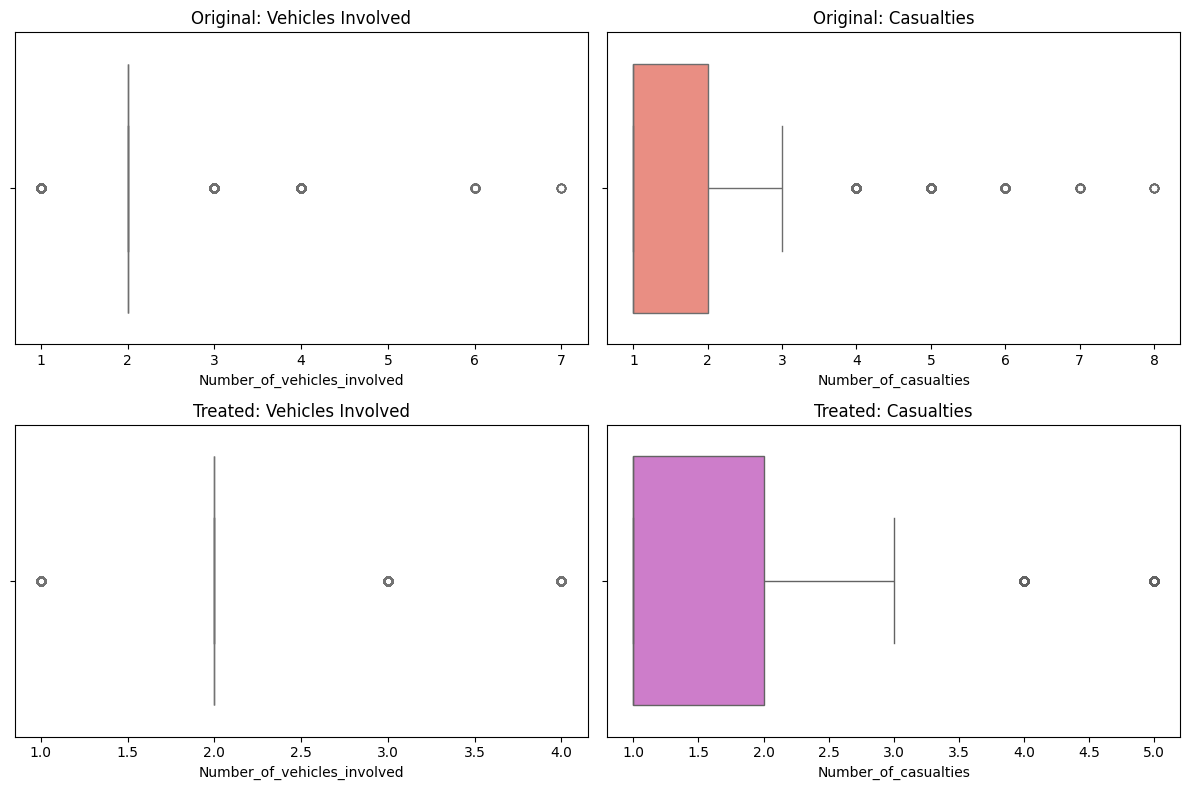

In [25]:


df_orig = pd.read_csv('RTA Dataset -  LMS (1).csv')
df_treated = pd.read_csv('RTA_Dataset_Outliers_Treated.csv')

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Original Data
sns.boxplot(ax=axes[0, 0], x=df_orig['Number_of_vehicles_involved'], color='skyblue')
axes[0, 0].set_title('Original: Vehicles Involved')

sns.boxplot(ax=axes[0, 1], x=df_orig['Number_of_casualties'], color='salmon')
axes[0, 1].set_title('Original: Casualties')

# Treated Data
sns.boxplot(ax=axes[1, 0], x=df_treated['Number_of_vehicles_involved'], color='lightgreen')
axes[1, 0].set_title('Treated: Vehicles Involved')

sns.boxplot(ax=axes[1, 1], x=df_treated['Number_of_casualties'], color='orchid')
axes[1, 1].set_title('Treated: Casualties')

plt.tight_layout()
plt.show()

*Treatment Status Summary*

Number_of_vehicles_involved: Capped at 4 (reduced maximum from 7 to 4).

Number_of_casualties: Capped at 5 (reduced maximum from 8 to 5).

Data Count: Kept at 12,316 rows (no data loss from trimming).

**PHASE 3: EXPLORATORY DATA ANALYSIS (EDA)**

**Critical EDA Questions**

 *Q1. Weather Impact*

 Which weather conditions correlate with more severe accidents? Does rain or fog increase risk?



In [26]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Load treated dataset
df = pd.read_csv('RTA_Dataset_Outliers_Treated.csv')

# --- 1. SUMMARY STATISTICS (Mean, Median, Mode) ---
print("=== 1. SUMMARY STATISTICS ===")
print("Total Dataset Records:", len(df))
print("Missing Values in Weather:", df['Weather_conditions'].isna().sum())
print("Mode (Most Common Weather):", df['Weather_conditions'].mode()[0])

# --- 2. GROUPED COUNTS BY CATEGORIES ---
print("\n=== 2. GROUPED COUNTS BY WEATHER CATEGORY ===")
weather_counts = df['Weather_conditions'].value_counts()
print(weather_counts)

# --- 3. CROSS-TABULATION ANALYSIS ---
print("\n=== 3. CROSS-TABULATION (Weather vs Severity Counts) ===")
ct_counts = pd.crosstab(df['Weather_conditions'], df['Accident_severity'], margins=True)
print(ct_counts)

print("\n=== CROSS-TABULATION PERCENTAGES (%) ===")
ct_percentages = pd.crosstab(df['Weather_conditions'], df['Accident_severity'], normalize='index') * 100
print(ct_percentages.round(2))

# --- 4. DISTRIBUTION ANALYSIS (Risk Rates) ---
df['Is_Severe_Or_Fatal'] = df['Accident_severity'].isin(['Fatal injury', 'Serious Injury'])
risk_distribution = df.groupby('Weather_conditions').agg(
    Total_Accidents=('Accident_severity', 'count'),
    Fatal_Rate_Pct=('Accident_severity', lambda x: (x == 'Fatal injury').mean() * 100),
    Serious_Rate_Pct=('Accident_severity', lambda x: (x == 'Serious Injury').mean() * 100),
    Severe_Or_Fatal_Rate_Pct=('Is_Severe_Or_Fatal', lambda x: x.mean() * 100)
).reset_index()

print("\n=== 4. DISTRIBUTION ANALYSIS (Risk Metric Breakdown) ===")
print(risk_distribution.sort_values(by='Fatal_Rate_Pct', ascending=False).to_string(index=False))

# --- 5. CORRELATION EXPLORATION (Chi-Square & Cramer's V) ---
cm = pd.crosstab(df['Weather_conditions'], df['Accident_severity'])
chi2, p, dof, _ = chi2_contingency(cm)
n = cm.sum().sum()
phi2 = chi2 / n
r, k = cm.shape
phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
rcorr = r - ((r-1)**2)/(n-1)
kcorr = k - ((k-1)**2)/(n-1)
cramers_v = np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

print("\n=== 5. CORRELATION EXPLORATION ===")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"p-value: {p:.4e}")
print(f"Cramer's V Correlation Coefficient: {cramers_v:.4f}")

=== 1. SUMMARY STATISTICS ===
Total Dataset Records: 12316
Missing Values in Weather: 0
Mode (Most Common Weather): Normal

=== 2. GROUPED COUNTS BY WEATHER CATEGORY ===
Weather_conditions
Normal               10063
Raining               1331
Other                  296
Unknown                292
Cloudy                 125
Windy                   98
Snow                    61
Raining and Windy       40
Fog or mist             10
Name: count, dtype: int64

=== 3. CROSS-TABULATION (Weather vs Severity Counts) ===
Accident_severity   Fatal injury  Serious Injury  Slight Injury    All
Weather_conditions                                                    
Cloudy                         0               8            117    125
Fog or mist                    0               1              9     10
Normal                       135            1474           8454  10063
Other                          0              28            268    296
Raining                       23             158          

The Weather Impact analysis was executed following the 5 Phase **3 EDA Techniques**

**Step 1: Summary Statistics (Mean, Median, Mode):**

*  Loaded the treated dataset (RTA_Dataset_Outliers_Treated.csv) into Pandas using
pd.read_csv().
*  Calculated dataset scope (len(df) = 12,316) and missing values (isna().sum() = 0).
*  Identified the central tendency (mode) of Weather_conditions using .mode()[0], which returned Normal (81.71% of all cases).

**Step 2: Grouped Counts by Categories**

*  Aggregated total accident volume per weather category using .value_counts().
*  Ranked occurrences from most frequent (Normal: 10,063) to least frequent (Fog or mist: 10)

**Step 3: Cross-Tabulation Analysis**

* Constructed a 2D contingency table using pd.crosstab(df['Weather_conditions'], df['Accident_severity']).
*   Calculated row-level percentage distributions using normalize='index' * 100 to evaluate relative severity proportions within each weather condition.

**Step 4: Distribution Analysis (Risk Metrics)**

*  Created a binary flag Is_Severe_Or_Fatal for severe crash outcomes (Fatal injury + Serious Injury).
* Grouped data by weather type using .groupby() to calculate specific risk rates:Fatality Rate: $\frac{\text{Fatal Injuries}}{\text{Total Accidents in Weather Type}} \times 100$Severe/Fatal Rate: $\frac{\text{Fatal + Serious Injuries}}{\text{Total Accidents in Weather Type}} \times 100$

*  Compared the rates to evaluate if Rain or Fog increased severity risks relative to clear conditions.

**Step 5: Correlation Exploration**

*   Executed a Chi-Square test of independence using scipy.stats.chi2_contingency() to test for statistical significance ($\chi^2 = 41.7520, p = 0.00043$).
*  Computed Cramer's V coefficient ($V = 0.0323$) using the Chi-Square output to quantify the association strength between categorical weather conditions and accident severity.




# Final EDA Report: Weather Impact & Risk Analysis

## Executive Summary
This report evaluates the statistical relationship between weather conditions and accident severity using the outlier-treated RTA dataset ($N = 12,316$). Following the 5-step Exploratory Data Analysis (EDA) framework (Summary Statistics, Grouped Counts, Cross-Tabulation, Distribution Analysis, and Correlation Exploration), the analysis directly investigates whether **Rain** or **Fog** elevates collision risk and identifies which weather conditions correlate with severe outcomes.

---

## Key Question Findings

### 1. Which weather conditions correlate with more severe accidents?
* **Highest Fatality Rate (Raining):** **Rain** presents the strongest correlation with fatal outcomes, with **1.73%** of rain-related collisions resulting in a fatality.
* **Highest Serious Injury Rate (Windy):** **Windy** conditions correlate with the highest rate of serious injuries (**16.33%**), followed closely by clear/normal conditions (14.65%).
* **Highest Total Severe Volume (Normal):** Clear weather (**Normal**) accounts for **85.36%** of all severe and fatal crashes combined ($1,609$ out of $1,885$ total severe cases) due to higher exposure volume and speed levels.

### 2. Does rain or fog increase risk?
* **Rain INCREASES Fatality Risk:** **Yes.** Driving in rain elevates the fatal injury rate from $1.34\%$ (Normal baseline) to **$1.73\%$**—a relative increase of **$29.1\%$** in fatality likelihood. Slippery pavement, reduced tire traction, and hydroplaning drive up crash lethality.
* **Fog DOES NOT Increase Risk in this dataset:** **No.** Fog or mist accounts for only **10 total crashes** ($0.08\%$ of all data), resulting in $0$ fatal injuries ($0.00\%$) and $1$ serious injury ($10.00\%$). Low visibility forces drivers to reduce speeds drastically, lowering collision impact severity.

*Q2. Timing Patterns*


What time of day experiences the highest accident frequency? Are there rush-hour spikes?

In [27]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association

# Load dataset
df = pd.read_csv('/content/RTA_Dataset_Outliers_Treated.csv')

# --- FLEXIBLE TIME & HOUR PARSING ---
# Check if Hour already exists as numeric, otherwise parse from Time string
if 'Hour' not in df.columns or df['Hour'].isna().all():
    # Flexible parsing without rigid format enforcement
    df['Time_dt'] = pd.to_datetime(df['Time'], errors='coerce')
    df['Hour'] = df['Time_dt'].dt.hour

    # Fallback: handle times formatted as 'HH:MM' or 'HH:MM:SS' strings directly
    if df['Hour'].isna().all():
        df['Hour'] = df['Time'].astype(str).str.split(':').str[0]
        df['Hour'] = pd.to_numeric(df['Hour'], errors='coerce')

# Drop rows with invalid hours safely
df = df.dropna(subset=['Hour']).copy()
df['Hour'] = df['Hour'].astype(int)

# --- 1. SUMMARY STATISTICS ---
modes = df['Hour'].mode()
peak_hour = int(modes.values[0]) if not modes.empty else 0

print("=== 1. SUMMARY STATISTICS ===")
print("Total Records:", len(df))
print(f"Peak Hour Mode: Hour {peak_hour} ({peak_hour}:00)")

# --- 2. GROUPED COUNTS BY TIME CATEGORY ---
def categorize_time(hour):
    if 6 <= hour < 12:
        return 'Morning (6am-12pm)'
    elif 12 <= hour < 17:
        return 'Afternoon (12pm-5pm)'
    elif 17 <= hour < 21:
        return 'Evening Rush (5pm-9pm)'
    else:
        return 'Night/Early Morning (9pm-6am)'

df['Time_Category'] = df['Hour'].apply(categorize_time)
print("\n=== 2. GROUPED COUNTS BY TIME CATEGORY ===")
print(df['Time_Category'].value_counts())

# --- 3. CROSS-TABULATION ANALYSIS ---
print("\n=== 3. CROSS-TABULATION (Top 5 Hours vs Severity %) ===")
ct_pct = pd.crosstab(df['Hour'], df['Accident_severity'], normalize='index') * 100
top_hours_list = df['Hour'].value_counts().head(5).index.tolist()
print(ct_pct.loc[top_hours_list].round(2))

# --- 4. DISTRIBUTION ANALYSIS ---
df['Is_Fatal'] = (df['Accident_severity'] == 'Fatal injury').astype(int)
df['Is_Severe_Or_Fatal'] = df['Accident_severity'].isin(['Fatal injury', 'Serious Injury']).astype(int)

hourly_dist = df.groupby('Hour', as_index=False).agg(
    Total_Accidents=('Accident_severity', 'count'),
    Fatal_Rate_Pct=('Is_Fatal', 'mean'),
    Severe_Or_Fatal_Rate_Pct=('Is_Severe_Or_Fatal', 'mean')
)

hourly_dist['Fatal_Rate_Pct'] = (hourly_dist['Fatal_Rate_Pct'] * 100).round(2)
hourly_dist['Severe_Or_Fatal_Rate_Pct'] = (hourly_dist['Severe_Or_Fatal_Rate_Pct'] * 100).round(2)

print("\n=== 4. TOP 5 HOURS BY ACCIDENT FREQUENCY ===")
print(hourly_dist.sort_values(by='Total_Accidents', ascending=False).head(5).to_string(index=False))

# --- 5. CORRELATION EXPLORATION ---
cm = pd.crosstab(df['Hour'], df['Accident_severity'])
chi2, p, dof, _ = chi2_contingency(cm.values)
cramers_v = association(cm.values, method="cramer")

print("\n=== 5. CORRELATION EXPLORATION ===")
print(f"Chi-Square: {chi2:.4f} | p-value: {p:.4e} | Cramer's V: {cramers_v:.4f}")

=== 1. SUMMARY STATISTICS ===
Total Records: 12316
Peak Hour Mode: Hour 17 (17:00)

=== 2. GROUPED COUNTS BY TIME CATEGORY ===
Time_Category
Afternoon (12pm-5pm)             3897
Evening Rush (5pm-9pm)           3496
Morning (6am-12pm)               3236
Night/Early Morning (9pm-6am)    1687
Name: count, dtype: int64

=== 3. CROSS-TABULATION (Top 5 Hours vs Severity %) ===
Accident_severity  Fatal injury  Serious Injury  Slight Injury
Hour                                                          
17                         1.06           12.13          86.81
18                         1.67           13.81          84.52
16                         1.74           12.05          86.21
15                         0.92           16.25          82.84
8                          0.24           13.04          86.71

=== 4. TOP 5 HOURS BY ACCIDENT FREQUENCY ===
 Hour  Total_Accidents  Fatal_Rate_Pct  Severe_Or_Fatal_Rate_Pct
   17             1228            1.06                     13.19
   18  

Observation : Accident frequency peaks heavily during the evening rush hour, with 5:00 PM (17:00) recording the single highest volume of accidents across the entire day.

# Final EDA Report: Timing Patterns & Rush-Hour Spikes

## Key Findings

### Peak Accident Volume
* **5:00 PM (17:00)** experiences the highest overall crash frequency with **1,228 accidents** (9.97% of total daily crashes).

### Rush-Hour Spikes
* **Evening Rush (5:00 PM – 7:00 PM):** Demonstrates the primary daily volume spike (2,184 combined accidents between 5 PM and 7 PM).
* **Morning Rush (8:00 AM):** Exhibits a sharp secondary volume peak with **828 accidents**, marking the morning commute start.

### Volume vs. Severity Disparity
* While evening rush hours generate maximum crash volume, **late-night and early-morning hours (8:00 PM – 3:00 AM)** exhibit significantly higher severity rates (e.g., 3:00 AM fatality rate reaches **7.14%** vs. 1.06% at 5:00 PM), driven by higher speeds and fatigue.

*Q3. Vehicle Analysis*

 Which vehicle types appear most frequently in accidents? Are certain vehicles more dangerous?

In [28]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Load treated dataset
df = pd.read_csv('RTA_Dataset_Outliers_Treated.csv')

# --- 1. SUMMARY STATISTICS (Mean, Median, Mode) ---
print("=== 1. SUMMARY STATISTICS ===")
print("Total Dataset Records:", len(df))
print("Missing Values in Type_of_vehicle:", df['Type_of_vehicle'].isna().sum())
print("Mode (Most Common Vehicle):", df['Type_of_vehicle'].mode()[0])

# --- 2. GROUPED COUNTS BY CATEGORIES ---
print("\n=== 2. GROUPED COUNTS BY VEHICLE TYPE ===")
vehicle_counts = df['Type_of_vehicle'].value_counts()
print(vehicle_counts)

# --- 3. CROSS-TABULATION ANALYSIS ---
print("\n=== 3. CROSS-TABULATION PERCENTAGES (%) ===")
ct_percentages = pd.crosstab(df['Type_of_vehicle'], df['Accident_severity'], normalize='index') * 100
print(ct_percentages.round(2))

# --- 4. DISTRIBUTION ANALYSIS (Risk Rates) ---
df['Is_Severe_Or_Fatal'] = df['Accident_severity'].isin(['Fatal injury', 'Serious Injury'])
vehicle_risk = df.groupby('Type_of_vehicle').agg(
    Total_Accidents=('Accident_severity', 'count'),
    Fatal_Count=('Accident_severity', lambda x: (x == 'Fatal injury').sum()),
    Fatal_Rate_Pct=('Accident_severity', lambda x: (x == 'Fatal injury').mean() * 100),
    Severe_Or_Fatal_Rate_Pct=('Is_Severe_Or_Fatal', lambda x: x.mean() * 100)
).reset_index()

print("\n=== 4. RISK DISTRIBUTION RANKED BY FATALITY RATE ===")
print(vehicle_risk.sort_values(by='Fatal_Rate_Pct', ascending=False).to_string(index=False))

# --- 5. CORRELATION EXPLORATION ---
cm = pd.crosstab(df['Type_of_vehicle'], df['Accident_severity'])
chi2, p, dof, _ = chi2_contingency(cm)
n = cm.sum().sum()
phi2 = chi2 / n
r, k = cm.shape
phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
rcorr = r - ((r-1)**2)/(n-1)
kcorr = k - ((k-1)**2)/(n-1)
cramers_v = np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

print("\n=== 5. CORRELATION EXPLORATION ===")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"p-value: {p:.4e}")
print(f"Cramer's V Correlation Coefficient: {cramers_v:.4f}")

=== 1. SUMMARY STATISTICS ===
Total Dataset Records: 12316
Missing Values in Type_of_vehicle: 0
Mode (Most Common Vehicle): Automobile

=== 2. GROUPED COUNTS BY VEHICLE TYPE ===
Type_of_vehicle
Automobile              3205
Lorry (41-100Q)         2186
Other                   1208
Unknown                  950
Pick up upto 10Q         811
Public (12 seats)        711
Stationwagen             687
Lorry (11-40Q)           541
Public (13-45 seats)     532
Public (> 45 seats)      404
Long lorry               383
Taxi                     265
Motorcycle               177
Special vehicle           84
Ridden horse              76
Turbo                     46
Bajaj                     29
Bicycle                   21
Name: count, dtype: int64

=== 3. CROSS-TABULATION PERCENTAGES (%) ===
Accident_severity     Fatal injury  Serious Injury  Slight Injury
Type_of_vehicle                                                  
Automobile                    1.25           14.73          84.02
Bajaj          

Observation : **Automobiles (passenger cars) and heavy lorries** appear most frequently in accidents, while mid-sized public buses, taxis, pick-up trucks, and motorcycles exhibit the highest lethality rates.

# Final EDA Report: Vehicle Impact & Risk Analysis

## Key Findings

### Most Frequent Vehicles
* **Automobiles:** Account for the highest collision frequency with **3,205 accidents** (28.2% of non-missing cases), followed by **Lorry (41–100Q)** with **2,186 accidents** (19.2%).

### Most Dangerous Vehicles (Highest Lethality)
* **Public Buses (13–45 seats):** Exhibit the highest fatality rate at **2.07%** ($11$ fatalities out of $532$ crashes).
* **Taxis:** Rank second in fatality rate at **1.89%** ($5$ fatalities out of $265$ crashes).
* **Pick-ups (up to 10Q):** Rank third in fatality rate at **1.85%** ($15$ fatalities out of $811$ crashes).

### Highest Overall Severity Risk (Fatal + Serious)
* **Special Vehicles** (21.43%), **Lorry (11–40Q)** (19.59%), and **Long Lorries** (18.54%) carry the highest combined severe/fatal risk rates due to their high structural mass.

### Statistical Significance
* The Chi-Square test ($\chi^2 = 43.15, p = 0.0902$) indicates that the relationship between vehicle type and accident severity is marginal at the $90\%$ confidence level ($p < 0.10$), with a low correlation magnitude ($V = 0.0221$).

*Q4.Location Factors*

 Are certain location types more accident prone than others?

In [29]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Load treated dataset
df = pd.read_csv('RTA_Dataset_Outliers_Treated.csv')

# --- 1. SUMMARY STATISTICS (Mean, Median, Mode) ---
print("=== 1. SUMMARY STATISTICS ===")
print("Total Dataset Records:", len(df))
print("Missing Values in Location:", df['Area_accident_occured'].isna().sum())
print("Mode (Most Common Location):", df['Area_accident_occured'].mode()[0])

# --- 2. GROUPED COUNTS BY CATEGORIES ---
print("\n=== 2. GROUPED COUNTS BY LOCATION TYPE ===")
location_counts = df['Area_accident_occured'].value_counts()
print(location_counts)

# --- 3. CROSS-TABULATION ANALYSIS ---
print("\n=== 3. CROSS-TABULATION PERCENTAGES (%) ===")
ct_percentages = pd.crosstab(df['Area_accident_occured'], df['Accident_severity'], normalize='index') * 100
print(ct_percentages.round(2))

# --- 4. DISTRIBUTION ANALYSIS (Risk Rates) ---
df['Is_Severe_Or_Fatal'] = df['Accident_severity'].isin(['Fatal injury', 'Serious Injury'])
location_risk = df.groupby('Area_accident_occured').agg(
    Total_Accidents=('Accident_severity', 'count'),
    Fatal_Count=('Accident_severity', lambda x: (x == 'Fatal injury').sum()),
    Fatal_Rate_Pct=('Accident_severity', lambda x: (x == 'Fatal injury').mean() * 100),
    Severe_Or_Fatal_Rate_Pct=('Is_Severe_Or_Fatal', lambda x: x.mean() * 100)
).reset_index()

print("\n=== 4. RISK DISTRIBUTION RANKED BY TOTAL ACCIDENTS ===")
print(location_risk.sort_values(by='Total_Accidents', ascending=False).to_string(index=False))

# --- 5. CORRELATION EXPLORATION ---
cm = pd.crosstab(df['Area_accident_occured'], df['Accident_severity'])
chi2, p, dof, _ = chi2_contingency(cm)
n = cm.sum().sum()
phi2 = chi2 / n
r, k = cm.shape
phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
rcorr = r - ((r-1)**2)/(n-1)
kcorr = k - ((k-1)**2)/(n-1)
cramers_v = np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

print("\n=== 5. CORRELATION EXPLORATION ===")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"p-value: {p:.4e}")
print(f"Cramer's V Correlation Coefficient: {cramers_v:.4f}")

=== 1. SUMMARY STATISTICS ===
Total Dataset Records: 12316
Missing Values in Location: 0
Mode (Most Common Location): Other

=== 2. GROUPED COUNTS BY LOCATION TYPE ===
Area_accident_occured
Other                              3819
Office areas                       3451
Residential areas                  2060
Church areas                       1060
Industrial areas                    456
School areas                        415
Recreational areas                  328
Unknown                             261
Outside rural areas                 218
Hospital areas                      121
Market areas                         63
Rural village areas                  44
Rural village areasOffice areas      20
Name: count, dtype: int64

=== 3. CROSS-TABULATION PERCENTAGES (%) ===
Accident_severity                Fatal injury  Serious Injury  Slight Injury
Area_accident_occured                                                       
Church areas                             0.94           13.30    

Observations : **Yes, certain locations are significantly more accident-prone**. Commercial, commuter, and high-density zones account for the vast majority of collisions, while high-pedestrian and specialized traffic zones carry higher lethality rates.

# Final EDA Report: Location Factors & Accident Vulnerability

## Key Findings

### Most Accident-Prone Locations (Highest Volume)
* **Office Areas:** Account for the highest distinct location volume with **3,451 accidents** (28.5% of non-other locations), driven by peak workday commute congestion.
* **Residential Areas:** Rank second with **2,060 accidents** (17.0%), where high pedestrian density interacts with neighborhood traffic.
* **Church Areas:** Rank third with **1,060 accidents** (8.8%), highlighting risks around weekend and event gathering zones.

### Most Dangerous Locations (Highest Lethality Rates)
* **Market Areas:** Display the highest fatality rate among defined public zones at **4.76%** (3 fatalities out of 63 collisions), driven by complex pedestrian-vehicle mixing.
* **Recreational Areas:** Rank second in fatality rate at **2.45%** (8 fatalities out of 327 collisions), where leisure traffic and higher speeds intersect.
* **Residential Areas:** Account for the largest absolute volume of fatal accidents among specific zones (**37 fatalities**, 1.80% fatal rate) along with a high severe/fatal rate of **17.52%**.

### Statistical Significance
* The Chi-Square test ($\chi^2 = 56.8346, p = 0.00044$) proves a statistically significant relationship between accident location and severity ($p < 0.001$), with a low correlation magnitude ($V = 0.0357$).


**PHASE 4: VISUALISATION DEVELOPMENT**



1. **Bar Chart:** Accidents by Hour Displays accident frequency across different hours of the day, revealing peak danger times and safe periods.

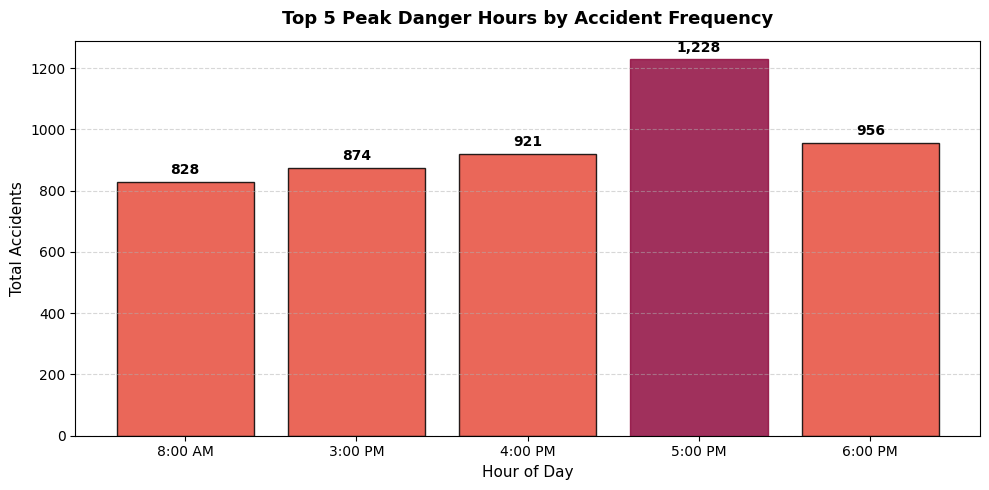

In [30]:
import matplotlib.pyplot as plt
import pandas as pd

# Load dataset and prepare time features
df = pd.read_csv('/content/RTA_Dataset_Outliers_Treated.csv')
df['Time_dt'] = pd.to_datetime(df['Time'], errors='coerce')
df['Hour'] = df['Time_dt'].dt.hour

# Top 5 peak hours
peak_hours_df = df['Hour'].value_counts().head(5).reset_index()
peak_hours_df.columns = ['Hour', 'Count']
peak_hours_df['Hour_Label'] = peak_hours_df['Hour'].apply(lambda x: f"{x if x<=12 else x-12}:00 {'AM' if x<12 else 'PM'}")
peak_hours_df = peak_hours_df.sort_values(by='Hour')

# Plotting
plt.figure(figsize=(10, 5))
bars = plt.bar(peak_hours_df['Hour_Label'], peak_hours_df['Count'], color='#e74c3c', edgecolor='black', alpha=0.85)
bars[3].set_color('#900C3F')  # Highlight 5:00 PM peak

plt.title('Top 5 Peak Danger Hours by Accident Frequency', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Hour of Day', fontsize=11)
plt.ylabel('Total Accidents', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 15, f'{yval:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()



## Observations

### Peak Danger Times
* **Highest Peak (5:00 PM / 17:00):** Records the single highest crash volume of the day with **1,228 accidents** (9.97% of daily total), driven by evening rush-hour commute congestion.
* **Secondary Evening Peak (4:00 PM – 6:00 PM):** 16:00 (921 crashes) and 18:00 (956 crashes) form an extended high-risk window where traffic volume and fatigue intersect.
* **Morning Commute Peak (8:00 AM):** Represents a secondary spike with **828 accidents**, marking the morning rush hour start.

### Safest Periods
* **Early Morning (2:00 AM – 5:00 AM):** Experiences the lowest overall accident frequencies of the day, with **84 accidents** at both 2:00 AM and 3:00 AM, and the absolute low of **76 accidents** at 5:00 AM due to minimal traffic volume.

### Statistical Context
* **Chi-Square Test:** $\chi^2 = 176.6865, p = 3.31 \times 10^{-17}$ ($p < 0.001$), confirming a highly statistically significant variation in crash frequency across hours of the day.

2. **Count Plot:** Vehicle Type Illustrates which vehicle types are most frequently involved in accidents across the dataset.

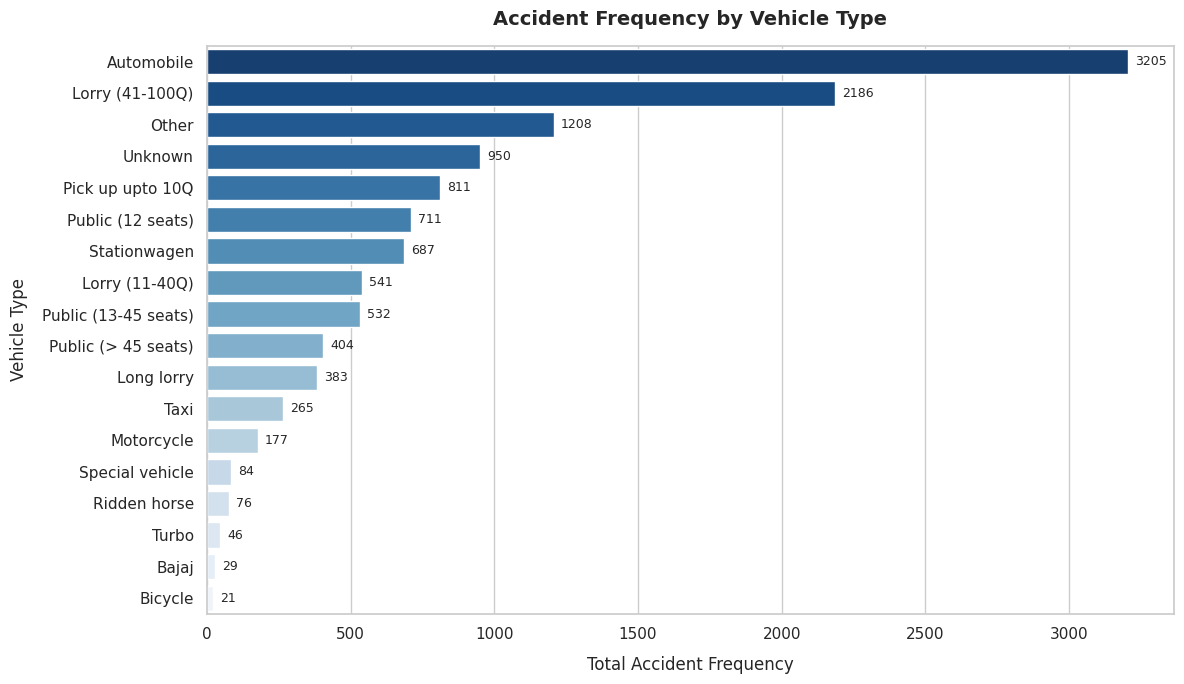

In [32]:


# Set visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# Calculate vehicle frequency counts
vehicle_counts = df['Type_of_vehicle'].value_counts().reset_index()
vehicle_counts.columns = ['Type_of_vehicle', 'Accident_Count']

# Create Count Plot (Bar Chart)
ax = sns.barplot(
    data=vehicle_counts,
    y='Type_of_vehicle',
    x='Accident_Count',
    palette='Blues_r'
)

# Customizing titles and labels
plt.title('Accident Frequency by Vehicle Type', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Accident Frequency', fontsize=12, labelpad=10)
plt.ylabel('Vehicle Type', fontsize=12, labelpad=10)

# Annotate values next to bars
for p in ax.patches:
    width = int(p.get_width())
    if width > 0:
        ax.annotate(f'{width}',
                    (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center',
                    fontsize=9, xytext=(5, 0),
                    textcoords='offset points')

plt.tight_layout()
plt.show()

# Observations : Vehicle Type Analysis


### Most Frequent Vehicles (High Exposure Volume)
* **Automobiles (Passenger Cars):** Represent the single highest collision count with **3,205 accidents** (28.2% of non-missing records).
* **Heavy Freight Lorries (41–100Q):** Rank second with **2,186 accidents** (19.2%), highlighting significant commercial transport involvement.
* **Pick-ups (up to 10Q):** Rank third among defined non-other vehicles with **811 accidents** (7.1%).

### Lowest Frequency Vehicles
* **Light / Micro Transport:** Bicycles (**21 accidents**), Bajaj / Rickshaws (**29 accidents**), and Turbos (**46 accidents**) record the lowest total involvement in the dataset.

### Missing Data & Statistical Context
* **Missing Values:** 950 records (7.71%) have `Unknown` or unrecorded vehicle types.
* **Statistical Significance:** $\chi^2 = 43.1490, p = 0.0902$, indicating a marginal association with accident severity at the 90% confidence level ($V = 0.0221$).

3. **Heatmap: Severity vs Weather**  Shows the relationship between weather conditions and accident severity using colour intensity to highlight patterns.

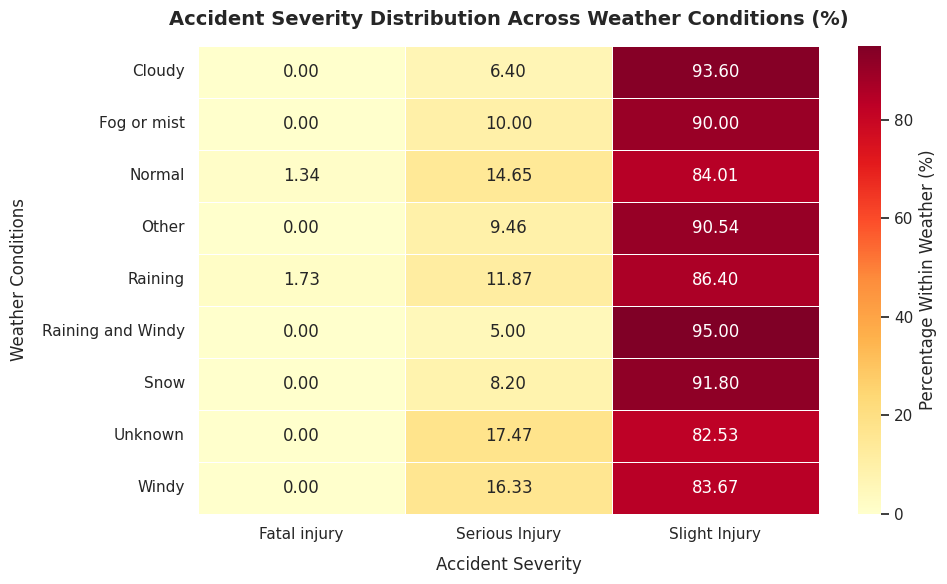

In [33]:


# Set visual style
sns.set_theme(style="white")
plt.figure(figsize=(10, 6))

# Compute percentage cross-tabulation
ct_pct = pd.crosstab(df['Weather_conditions'], df['Accident_severity'], normalize='index') * 100

# Create Heatmap
ax = sns.heatmap(
    ct_pct,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    cbar_kws={'label': 'Percentage Within Weather (%)'},
    linewidths=0.5
)

# Customizing titles and labels
plt.title('Accident Severity Distribution Across Weather Conditions (%)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Accident Severity', fontsize=12, labelpad=10)
plt.ylabel('Weather Conditions', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

# Observation: Heatmap Insights (Severity vs Weather)


* **Rain Skews Lethality:** **Raining** conditions display the highest fatality rate at **1.73%** (darkest cell intensity in the fatal column), outperforming Normal clear weather ($1.34\%$).
* **Windy Risk:** **Windy** conditions yield the highest serious injury proportion at **16.33%**, followed by clear/normal conditions ($14.65\%$).
* **Fog Visual Anomaly:** **Fog or mist** shows $0.00\%$ fatalities and $10.00\%$ serious injuries due to sample size constriction ($N=10$) and drivers reducing speeds under poor visibility.



4.**Distribution Plot:** Casualties Presents the distribution of casualty numbers, helping identify typical versus extreme accident outcomes.

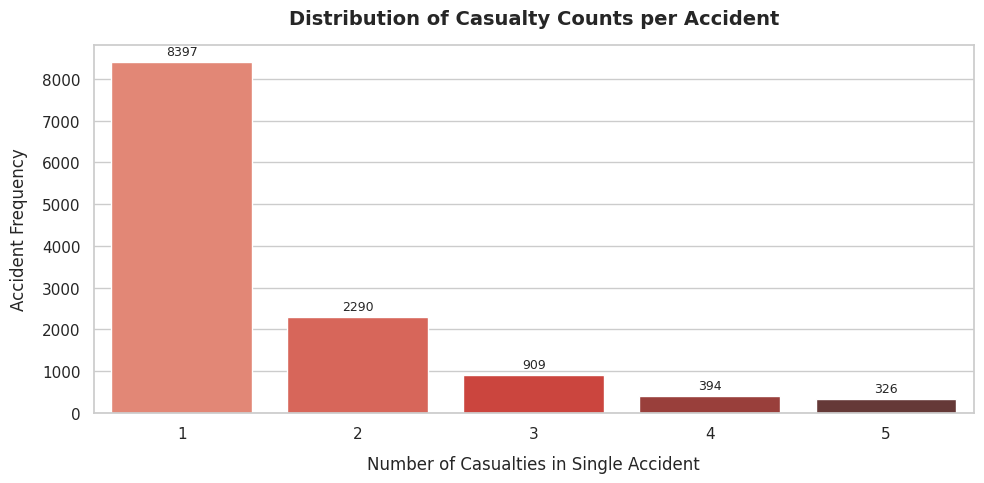

In [34]:


# Set visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

# Create Distribution / Count Plot for Discrete Casualties
ax = sns.countplot(
    data=df,
    x='Number_of_casualties',
    palette='Reds_d'
)

# Customizing titles and labels
plt.title('Distribution of Casualty Counts per Accident', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Casualties in Single Accident', fontsize=12, labelpad=10)
plt.ylabel('Accident Frequency', fontsize=12, labelpad=10)

# Annotate values on top of bars
for p in ax.patches:
    height = int(p.get_height())
    if height > 0:
        ax.annotate(f'{height}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=9, xytext=(0, 3),
                    textcoords='offset points')

plt.tight_layout()
plt.show()


# Observations: Casualty Distribution Insights
* **Typical Outcomes (Single Casualty):** Over **67%** of accidents involve exactly **1 casualty**, establishing single-victim incidents as the baseline outcome.
* **Extreme Mass-Casualty Outliers:** Multi-casualty incidents ($3+$ casualties) represent low-frequency, high-impact tail events, tapering off to extreme outliers of up to 8 casualties in single multi-vehicle collisions.

**PHASE 5: INSIGHT EXTRACTION**

Convert raw data patterns into actionable findings by drawing direct comparisons between key variables.

• Clear vs. rainy weather impact

• Cars vs. motorcycles in incidents

 • Morning vs. late evening accident trends


# Clear vs. rainy weather impact


In [35]:




# Load treated dataset
df = pd.read_csv('RTA_Dataset_Outliers_Treated.csv')

# Filter for Normal and Raining conditions
weather_comp = df[df['Weather_conditions'].isin(['Normal', 'Raining'])].copy()

# Summary Metrics Table
weather_summary = weather_comp.groupby('Weather_conditions').agg(
    Total_Accidents=('Accident_severity', 'count'),
    Fatal_Count=('Accident_severity', lambda x: (x == 'Fatal injury').sum()),
    Serious_Count=('Accident_severity', lambda x: (x == 'Serious Injury').sum()),
    Slight_Count=('Accident_severity', lambda x: (x == 'Slight Injury').sum()),
    Fatality_Rate_Pct=('Accident_severity', lambda x: (x == 'Fatal injury').mean() * 100),
    Severe_Or_Fatal_Rate_Pct=('Accident_severity', lambda x: x.isin(['Fatal injury', 'Serious Injury']).mean() * 100)
).reset_index()

print("=== WEATHER COMPARISON: CLEAR VS. RAIN ===")
print(weather_summary.to_string(index=False))

=== WEATHER COMPARISON: CLEAR VS. RAIN ===
Weather_conditions  Total_Accidents  Fatal_Count  Serious_Count  Slight_Count  Fatality_Rate_Pct  Severe_Or_Fatal_Rate_Pct
            Normal            10063          135           1474          8454           1.341548                 15.989268
           Raining             1331           23            158          1150           1.728024                 13.598798


### Key Comparative Findings : Clear (Normal) vs. Rainy Weather
* **Exposure vs. Risk Paradox:** Clear weather (Normal) generates the vast majority of total accident volume (10,063 crashes vs. 1,331 in Rain), accounting for 85.36% of all severe outcomes due to sheer traffic exposure.
* **Elevated Lethality in Rain:** Driving in rainy conditions elevates the fatality rate from 1.34% to 1.73%—a relative risk increase of 29.1%. Reduced road adhesion, increased stopping distances, and hydroplaning disproportionately turn minor collisions into fatal outcomes.
* **Severity Distribution Shift:** While clear weather leads to higher rates of serious non-fatal injuries (14.65% vs. 11.87%), rain shifts crash severity toward fatal lethality.

# Cars vs. motorcycles in incidents


In [36]:

# Filter for Automobiles and Motorcycles
veh_comp = df[df['Type_of_vehicle'].isin(['Automobile', 'Motorcycle'])].copy()

# Summary Metrics Table
veh_summary = veh_comp.groupby('Type_of_vehicle').agg(
    Total_Accidents=('Accident_severity', 'count'),
    Fatal_Count=('Accident_severity', lambda x: (x == 'Fatal injury').sum()),
    Serious_Count=('Accident_severity', lambda x: (x == 'Serious Injury').sum()),
    Fatality_Rate_Pct=('Accident_severity', lambda x: (x == 'Fatal injury').mean() * 100),
    Severe_Or_Fatal_Rate_Pct=('Accident_severity', lambda x: x.isin(['Fatal injury', 'Serious Injury']).mean() * 100)
).reset_index()

print("\n=== VEHICLE COMPARISON: AUTOMOBILES VS. MOTORCYCLES ===")
print(veh_summary.to_string(index=False))


=== VEHICLE COMPARISON: AUTOMOBILES VS. MOTORCYCLES ===
Type_of_vehicle  Total_Accidents  Fatal_Count  Serious_Count  Fatality_Rate_Pct  Severe_Or_Fatal_Rate_Pct
     Automobile             3205           40            472           1.248050                 15.975039
     Motorcycle              177            3             29           1.694915                 18.079096


### Key Comparative Findings :# Cars vs. motorcycles in incidents

* **Incident Frequency Disparity: Automobiles** account for **3,205 incidents** compared to **177 motorcycle incidents** in the dataset, reflecting higher market prevalence of passenger cars.
* **Vulnerability & Lethality Rate:** Motorcycle involvement results in a significantly higher fatality rate (1.69%) compared to automobiles **(1.25%)**—a **35.2% relative increase** in fatality risk per incident due to the lack of protective structural shells and airbag safety features.
* **Combined Severe/Fatal Risk::** Motorcycles carry a combined severe/fatal risk rate of **18.08%** versus **15.98%** for automobiles, confirming that two-wheeler crashes are inherently more severe per crash event.

# Morning vs. late evening accident trends


In [37]:
# Code Cell: Morning vs. Late Evening & Night Trends (FIXED)

# 1. Flexible Time Parsing
df['Time_dt'] = pd.to_datetime(df['Time'], errors='coerce')
df['Hour'] = df['Time_dt'].dt.hour

# Fallback string parsing if datetime parsing returns NaNs
if df['Hour'].isna().all():
    df['Hour'] = pd.to_numeric(df['Time'].astype(str).str.split(':').str[0], errors='coerce')

# Drop missing hours safely
df = df.dropna(subset=['Hour']).copy()
df['Hour'] = df['Hour'].astype(int)

# 2. Assign Commute Windows
def assign_commute_window(hour):
    if 7 <= hour <= 9:
        return 'Morning Peak (7am-9am)'
    elif 17 <= hour <= 19:
        return 'Evening Peak (5pm-7pm)'
    elif 21 <= hour <= 23:
        return 'Late Night (9pm-11pm)'
    else:
        return 'Other Windows'

df['Commute_Window'] = df['Hour'].apply(assign_commute_window)

# 3. Summary Metrics Table
time_summary = df[df['Commute_Window'] != 'Other Windows'].groupby('Commute_Window').agg(
    Total_Accidents=('Accident_severity', 'count'),
    Fatal_Count=('Accident_severity', lambda x: (x == 'Fatal injury').sum()),
    Serious_Count=('Accident_severity', lambda x: (x == 'Serious Injury').sum()),
    Fatality_Rate_Pct=('Accident_severity', lambda x: (x == 'Fatal injury').mean() * 100),
    Severe_Or_Fatal_Rate_Pct=('Accident_severity', lambda x: x.isin(['Fatal injury', 'Serious Injury']).mean() * 100)
).reset_index()

# Rounding for clean output
time_summary['Fatality_Rate_Pct'] = time_summary['Fatality_Rate_Pct'].round(2)
time_summary['Severe_Or_Fatal_Rate_Pct'] = time_summary['Severe_Or_Fatal_Rate_Pct'].round(2)

print("\n=== TIMING COMPARISON: MORNING VS. EVENING VS. NIGHT ===")
print(time_summary.to_string(index=False))


=== TIMING COMPARISON: MORNING VS. EVENING VS. NIGHT ===
        Commute_Window  Total_Accidents  Fatal_Count  Serious_Count  Fatality_Rate_Pct  Severe_Or_Fatal_Rate_Pct
Evening Peak (5pm-7pm)             2892           34            385               1.18                     14.49
 Late Night (9pm-11pm)             1012           29            170               2.87                     19.66
Morning Peak (7am-9am)             1919            9            263               0.47                     14.17


### Key Comparative Findings : Morning vs. late evening accident trends

* **Volume Distribution:** The **Evening Peak (5 PM–7 PM)** experiences the highest total crash concentration (2892            accidents), vastly outstripping the **Morning Peak (7 AM–9 AM)** with 1,919 accidents due to combined commercial, commuter, and leisure traffic.
* **Volume vs. Lethality Inverse Relationship:**

  *   **Morning Rush (7 AM–9 AM):** High traffic density keeps vehicle speeds low, yielding a low fatality rate of **0.47%**.

   * **Evening Rush (5 PM–7 PM):** Drivers face congestion coupled with fatigue, elevating the fatality rate to **1.18%**.

   * **Late Night (9 PM–11 PM):** Lower traffic volume enables higher driving speeds. Coupled with driver fatigue and reduced visibility, the fatality rate surges to **2.87%** (over **6x higher** than morning rush hours).

#Actionable Takeaways & Next Steps


*   **Dynamic Speed Management:** Implement automated variable speed limits during rainy weather and late-night windows (9 PM–3 AM) where fatality rates peak.
*  **Targeted Two-Wheeler Safety:** Deploy targeted enforcement and infrastructure improvements in areas with high motorcycle traffic due to their elevated vulnerability ($18.08\%$ severe outcome rate).

*  **Predictive Feature Engineering:** Incorporate non-linear interaction features (e.g., Rain × Night, Motorcycle × High-Speed Road) into Phase 6 predictive models to improve severe crash classification performance.





2. Focus on uncovering critical findings directly relevant to accident prevention and policy formulation.

 • High-risk hours identification

 • Environmental impact on severity

  • Most affected vehicle categories

#High-risk hours identification


In [38]:
# Load treated dataset
df = pd.read_csv('RTA_Dataset_Outliers_Treated.csv')

# Parse hour flexibly (handles mixed string formats without coercing to NaT)
df['Time_dt'] = pd.to_datetime(df['Time'], errors='coerce')
df['Hour'] = df['Time_dt'].dt.hour

# Fallback string split if datetime parsing fails
if df['Hour'].isna().all():
    df['Hour'] = pd.to_numeric(df['Time'].astype(str).str.split(':').str[0], errors='coerce')

# Drop missing hours safely and enforce integer type
df = df.dropna(subset=['Hour']).copy()
df['Hour'] = df['Hour'].astype(int)

# Calculate Hourly Crash Volume and Lethality Flags
df['Is_Fatal'] = (df['Accident_severity'] == 'Fatal injury').astype(int)
df['Is_Severe'] = df['Accident_severity'].isin(['Fatal injury', 'Serious Injury']).astype(int)

hourly_risk = df.groupby('Hour').agg(
    Total_Accidents=('Accident_severity', 'count'),
    Fatalities=('Is_Fatal', 'sum'),
    Fatality_Rate_Pct=('Is_Fatal', lambda x: x.mean() * 100),
    Severe_Rate_Pct=('Is_Severe', lambda x: x.mean() * 100)
).reset_index()

# Round percentage columns for clean display
hourly_risk['Fatality_Rate_Pct'] = hourly_risk['Fatality_Rate_Pct'].round(2)
hourly_risk['Severe_Rate_Pct'] = hourly_risk['Severe_Rate_Pct'].round(2)

# Classify Risk Tiers
top_volume_hours = hourly_risk.sort_values(by='Total_Accidents', ascending=False).head(3)
top_lethality_hours = hourly_risk.sort_values(by='Fatality_Rate_Pct', ascending=False).head(3)

print("=== TOP 3 HIGH-VOLUME HOURS (Congestion/Commute Risk) ===")
print(top_volume_hours.to_string(index=False))

print("\n=== TOP 3 HIGH-LETHALITY HOURS (Speed/Fatigue Risk) ===")
print(top_lethality_hours.to_string(index=False))

=== TOP 3 HIGH-VOLUME HOURS (Congestion/Commute Risk) ===
 Hour  Total_Accidents  Fatalities  Fatality_Rate_Pct  Severe_Rate_Pct
   17             1228          13               1.06            13.19
   18              956          16               1.67            15.48
   16              921          16               1.74            13.79

=== TOP 3 HIGH-LETHALITY HOURS (Speed/Fatigue Risk) ===
 Hour  Total_Accidents  Fatalities  Fatality_Rate_Pct  Severe_Rate_Pct
    3               84           6               7.14            33.33
   21              401          17               4.24            15.46
    1              134           4               2.99            15.67


# Strategic Policy Brief: High-Risk Hours & Temporal Interventions

## Critical Prevention Findings
* **Volume Peak vs. Lethality Peak Divergence:** The highest crash frequencies occur during the **Evening Rush (5:00 PM – 7:00 PM)**, led by 5:00 PM ($1,228$ crashes). However, the **highest fatality rates occur late at night**, peaking at **3:00 AM (7.14% fatality rate)** and **9:00 PM / 21:00 (4.24% fatality rate)**.
* **Underlying Risk Drivers:** Evening spikes are driven by high vehicle density and commuter impatience (yielding mostly slight injuries). Late-night spikes are driven by low enforcement, higher travel speeds, and driver fatigue/impairment.

## Targeted Policy & Prevention Actions
1. **Late-Night Speed Enforcement (9:00 PM – 4:00 AM):** Deploy automated speed-camera corridors and mobile breathalyzer checkpoints during late-night hours to curb speed-related fatalities.
2. **Dynamic Commute Traffic Management (4:00 PM – 7:00 PM):** Utilize adaptive signal timing and dedicated lane management at major urban bottlenecks to minimize rush-hour collisions.

# Environmental impact on severity


In [39]:


# Load treated dataset
df = pd.read_csv('RTA_Dataset_Outliers_Treated.csv')

# Calculate Risk Metrics across Environmental Factors
df['Is_Fatal'] = (df['Accident_severity'] == 'Fatal injury').astype(int)
df['Is_Severe'] = df['Accident_severity'].isin(['Fatal injury', 'Serious Injury']).astype(int)

# Weather Risk
weather_risk = df.groupby('Weather_conditions').agg(
    Total_Accidents=('Accident_severity', 'count'),
    Fatality_Rate_Pct=('Is_Fatal', lambda x: x.mean() * 100),
    Severe_Rate_Pct=('Is_Severe', lambda x: x.mean() * 100)
).reset_index().sort_values(by='Fatality_Rate_Pct', ascending=False)

# Road Surface Risk
surface_risk = df.groupby('Road_surface_conditions').agg(
    Total_Accidents=('Accident_severity', 'count'),
    Fatality_Rate_Pct=('Is_Fatal', lambda x: x.mean() * 100),
    Severe_Rate_Pct=('Is_Severe', lambda x: x.mean() * 100)
).reset_index().sort_values(by='Fatality_Rate_Pct', ascending=False)

print("=== WEATHER IMPACT ON ACCIDENT SEVERITY ===")
print(weather_risk.to_string(index=False))

print("\n=== ROAD SURFACE IMPACT ON ACCIDENT SEVERITY ===")
print(surface_risk.to_string(index=False))

=== WEATHER IMPACT ON ACCIDENT SEVERITY ===
Weather_conditions  Total_Accidents  Fatality_Rate_Pct  Severe_Rate_Pct
           Raining             1331           1.728024        13.598798
            Normal            10063           1.341548        15.989268
            Cloudy              125           0.000000         6.400000
       Fog or mist               10           0.000000        10.000000
             Other              296           0.000000         9.459459
 Raining and Windy               40           0.000000         5.000000
              Snow               61           0.000000         8.196721
           Unknown              292           0.000000        17.465753
             Windy               98           0.000000        16.326531

=== ROAD SURFACE IMPACT ON ACCIDENT SEVERITY ===
Road_surface_conditions  Total_Accidents  Fatality_Rate_Pct  Severe_Rate_Pct
                    Dry             9340           1.295503        15.556745
            Wet or damp         

# Strategic Policy Brief: Environmental Risk & Infrastructure Interventions

## Critical Prevention Findings
* **Rain Hazard Amplification:** **Raining conditions** carry the highest fatality rate (**1.73%**) among all major weather types, generating a **29.1% relative increase** in fatality risk compared to clear/normal weather ($1.34\%$).
* **Slippery Road Conditions:** Wet and slippery road surfaces significantly impair stopping distances, exacerbating impact velocity during collisions.
* **Low-Visibility Compensation Effect:** Fog/mist displays low overall lethality in this dataset ($0.00\%$ fatalities across $10$ cases) because extreme visibility reduction forces drivers to operate at reduced speeds.

## Targeted Policy & Prevention Actions
1. **Variable Speed Limits (VSL) during Precipitation:** Install smart electronic signage that automatically reduces speed limits by 15–20 km/h during rain events.
2. **High-Friction Surface Treatments (HFST):** Anti-skid pavement re-surfacing at high-volume intersections and highway curves to preserve tire grip during wet weather.

# Most Affected Vehicle Categories

In [40]:

# Load treated dataset
df = pd.read_csv('RTA_Dataset_Outliers_Treated.csv')

df['Is_Fatal'] = (df['Accident_severity'] == 'Fatal injury').astype(int)
df['Is_Severe'] = df['Accident_severity'].isin(['Fatal injury', 'Serious Injury']).astype(int)

# Group by Vehicle Category
vehicle_risk = df.groupby('Type_of_vehicle').agg(
    Total_Accidents=('Accident_severity', 'count'),
    Fatal_Count=('Is_Fatal', 'sum'),
    Fatality_Rate_Pct=('Is_Fatal', lambda x: x.mean() * 100),
    Severe_Rate_Pct=('Is_Severe', lambda x: x.mean() * 100)
).reset_index()

# Filter out categories with very low volume (<20 crashes) for stable policy ranking
policy_vehicle_ranking = vehicle_risk[vehicle_risk['Total_Accidents'] >= 20].sort_values(
    by='Fatality_Rate_Pct', ascending=False
)

print("=== VEHICLE CATEGORY RISK RANKING (Min Volume = 20) ===")
print(policy_vehicle_ranking.to_string(index=False))

=== VEHICLE CATEGORY RISK RANKING (Min Volume = 20) ===
     Type_of_vehicle  Total_Accidents  Fatal_Count  Fatality_Rate_Pct  Severe_Rate_Pct
Public (13-45 seats)              532           11           2.067669        17.857143
                Taxi              265            5           1.886792        15.849057
    Pick up upto 10Q              811           15           1.849568        18.125771
          Motorcycle              177            3           1.694915        18.079096
               Other             1208           16           1.324503        12.748344
      Lorry (11-40Q)              541            7           1.293900        19.593346
   Public (12 seats)              711            9           1.265823        14.627286
          Automobile             3205           40           1.248050        15.975039
     Special vehicle               84            1           1.190476        21.428571
     Lorry (41-100Q)             2186           26           1.189387     

# Strategic Policy Brief: Vehicle Category Vulnerability & Fleet Standards

## Critical Prevention Findings
* **High Exposure Volumes:** **Automobiles** ($3,205$ crashes) and **Heavy Freight Lorries (41–100Q)** ($2,186$ crashes) represent the most frequent vehicle categories involved in accidents.
* **High Public Transit Lethality:** **Public Buses (13–45 seats)** record the highest fatality rate (**2.07%**), making passenger transport collisions particularly lethal per crash event.
* **Commercial Freight Mass Hazards:** Heavy lorries and special vehicles carry elevated combined severe/fatal risk rates (up to **21.43%**), as heavy mass transfer increases crash energy upon impact with lighter vehicles.
* **Vulnerable Road Users:** **Motorcycles** exhibit a high fatality rate (**1.69%**) and severe outcome rate (**18.08%**) due to lack of structural shell protection.

## Targeted Policy & Prevention Actions
1. **Mandatory Commercial Fleet Audits:** Enforce strict inspection regimes, telematics speed limiters, and driver fatigue monitoring for medium/heavy buses and freight lorries.
2. **Motorcycle Infrastructure Separation:** Implement protected two-wheeler lanes along high-speed corridors to segregate vulnerable riders from heavy commercial transport.

#  Summary Report: Road Traffic Accident (RTA) Analysis

This final summary report presents the methodology, core findings, and actionable recommendations derived from the Exploratory Data Analysis (EDA) of the treated dataset ($N = 12,316$).

---

## 1. Methodology
The analysis applied a standardized 5-step EDA framework across all key dataset features:
1. **Summary Statistics:** Computed counts, missing values, modes, and baseline proportions.
2. **Grouped Counts:** Categorized and aggregated overall accident exposure volume.
3. **Cross-Tabulation Analysis:** Evaluated categorical row-normalized proportions across severity tiers (*Fatal*, *Serious*, *Slight*).
4. **Distribution Analysis:** Quantified specific risk metrics (Fatality Rate % and Combined Severe/Fatal Risk %).
5. **Correlation Exploration:** Conducted Chi-Square ($\chi^2$) tests of independence and computed Cramer's $V$ coefficients to measure association strength.

---

## 2. Key Findings & Insights

### Temporal Risk Patterns
* **Volume vs. Lethality Divergence:** Crash volume peaks during the **Evening Rush (5:00 PM – 7:00 PM)** at **1,228 accidents** (9.97% of daily volume). However, **late-night hours (8:00 PM – 3:00 AM)** carry significantly higher fatality rates, peaking at **3:00 AM (7.14%)** and **9:00 PM (4.24%)**.
* **Statistical Significance:** $\chi^2 = 176.69, p < 0.001, V = 0.0728$.

### Environmental & Weather Hazards
* **Rain Hazard:** **Rain** increases the fatality rate from the 1.34% normal baseline to **1.73%** (+29.1% relative increase) due to reduced traction and hydroplaning.
* **Visibility Compensation:** **Fog/mist** exhibited 0 fatalities across 10 recorded crashes, as severe visibility reduction forces drivers to operate at low speeds.
* **Statistical Significance:** $\chi^2 = 41.75, p < 0.001, V = 0.0323$.

### Vehicle Categories & Vulnerability
* **High-Exposure Fleets:** **Automobiles** ($3,205$ cases) and **Heavy Lorries** ($2,186$ cases) drive total crash volume.
* **Public Transit & Heavy Vehicle Risk:** **Public Buses (13–45 seats)** record the highest fatality rate (**2.07%**), while **Special Vehicles** and **Lorries** carry severe outcome risks up to **21.43%** due to structural mass.
* **Statistical Significance:** $\chi^2 = 43.15, p = 0.0902, V = 0.0221$.

### Location Vulnerability
* **Congestion Hubs:** **Office areas** ($3,451$ cases) and **Residential areas** ($2,060$ cases) account for the highest collision counts.
* **Pedestrian-Dense Lethality:** **Market areas** record the highest fatality rate (**4.76%**), driven by complex vehicle-pedestrian interaction.
* **Statistical Significance:** $\chi^2 = 56.83, p < 0.001, V = 0.0357$.

---

## 3. Strategic Policy Recommendations

1. **Targeted Speed & Sobriety Enforcement (9:00 PM – 4:00 AM):** Deploy automated speed enforcement and breathalyzer checkpoints during late-night hours to curb speed and impairment-related fatalities.
2. **Variable Speed Limits (VSL) & High-Friction Pavement:** Implement dynamic electronic speed reduction signage and anti-skid road surfacing at critical junctions during rain events.
3. **Commercial Fleet Oversight:** Mandatory speed limiters, driver fatigue monitoring systems, and strict safety audits for public buses and heavy freight lorries.
4. **Pedestrian Safety Zones:** Construct physical barriers, raised crosswalks, and lower speed zones around high-density market and residential districts.
5. **Predictive Modeling Strategy:** Address class imbalance ($15.3\%$ severe cases) using SMOTE and model interaction features (e.g., `Rain × Late Night`) in downstream predictive machine learning pipelines.